# NYC Green Taxi 2023 — trip insights on InterSystems IRIS

A prototype that loads a year of green-taxi trips (787,060 rows) into IRIS,
decides which of them are believable, enriches both ends of every trip with
borough and zone names, and answers four analyst questions — with the work done
inside the database and only the answers coming back to Python.

**How to read this notebook.** Every cell below runs against a live IRIS
container; nothing here is pasted output. The chain that produced its inputs is
four scripts, in order:

| Step | Script | What it leaves behind |
|---|---|---|
| Profile the raw CSV | `src/profile_trips.py` | the numbers that chose the schema and the quality rules |
| Validate, then load | `src/validate_trips.py`, `src/load_trips.py`, `src/load_zones.py` | `Taxi.Trip` (787,060), `Taxi.Zone` (265), `Taxi.TripReject` (0) |
| Define quality | `src/build_quality.py` | views `Taxi.TripQuality`, `Taxi.SuspectTrip` |
| Define enrichment | `src/build_enriched.py` | view `Taxi.TripEnriched` |

Re-run those four and this notebook reproduces from scratch.

In [1]:
import os
import sys
import time

# The notebook may be opened with the repo root or notebooks/ as the working
# directory depending on the tool (VS Code uses the file's folder, `jupyter lab`
# from the root uses the root). Adding both candidates is one line and removes
# a class of "works on my machine".
for path in ("src", "../src"):
    if os.path.isdir(path) and path not in sys.path:
        sys.path.insert(0, path)

import matplotlib.pyplot as plt
import pandas as pd

import analytics
import plotstyle
from build_quality import INFO_RULES, RULES, SUSPECT_RULES
from iris_conn import query

plotstyle.apply_style()

total_trips = query("SELECT COUNT(*) FROM Taxi.Trip")[1][0][0]
suspect_trips = query("SELECT COUNT(*) FROM Taxi.SuspectTrip")[1][0][0]
zones = query("SELECT COUNT(*) FROM Taxi.Zone")[1][0][0]
rejected = query("SELECT COUNT(*) FROM Taxi.TripReject")[1][0][0]

print(f"Taxi.Trip        {total_trips:>9,} rows")
print(f"Taxi.Zone        {zones:>9,} rows")
print(f"Taxi.TripReject  {rejected:>9,} rows   <- rows that could not be typed at all")
print(f"Taxi.SuspectTrip {suspect_trips:>9,} rows   "
      f"({suspect_trips / total_trips * 100:.2f}% of the year)")

Taxi.Trip          787,060 rows
Taxi.Zone              265 rows
Taxi.TripReject          0 rows   <- rows that could not be typed at all
Taxi.SuspectTrip    57,058 rows   (7.25% of the year)


## Part 1 — Which trips are believable?

Two questions get asked separately, and keeping them apart is the main design
decision in this project:

* **Can the row be typed?** Answered before anything is loaded, by
  `src/validate_trips.py` against the column definitions in `src/schema.py`.
  For the supplied file the answer is yes 787,060 times out of 787,060 —
  `Taxi.TripReject` is empty. Getting there needed two fixes that a naive load
  gets silently wrong: `MM/DD/YYYY hh:mm:ss AM/PM` timestamps, and 578 numeric
  values written with a thousands separator (`1,069.67`) inside a quoted field.
  Drop those 578 and you lose *the largest values in their columns* — the very
  records a quality exercise exists to find.
* **Is the row believable?** Answered *after* loading, in SQL, by the thirteen
  rules below. A row with `trip_distance = 0` and `fare_amount = -500` is
  structurally perfect, so it loads; deciding it is questionable is a separate
  opinion that lives in a view and can be re-argued in seconds without touching
  787,060 stored rows.

In [2]:
# One pass over Taxi.TripQuality returns every rule's hit count. The CASE
# expressions live in the view, so this is 16 numbers crossing the wire.
sums = ", ".join(f"SUM({r.code}) AS {r.code}" for r in RULES)
counts = analytics.read(f"SELECT {sums} FROM Taxi.TripQuality")

rules_table = pd.DataFrame({
    "rule": [r.code for r in RULES],
    "severity": [r.severity for r in RULES],
    "trips": [int(counts[r.code].iloc[0]) for r in RULES],
})
rules_table["share_%"] = (rules_table.trips / total_trips * 100).round(3)
rules_table.sort_values(["severity", "trips"], ascending=[True, False],
                        ignore_index=True)

,rule,severity,trips,share_%
0,component_sum_mismatch,info,115015,14.613
1,missing_trip_metadata,info,55613,7.066
2,pickup_outside_2023,info,7,0.001
3,zero_distance,suspect,39494,5.018
4,charged_without_moving,suspect,38087,4.839
5,duration_under_1min,suspect,20563,2.613
6,zero_passengers,suspect,6143,0.780
7,implausible_speed,suspect,2697,0.343
8,duration_over_12h,suspect,2487,0.316
9,negative_total,suspect,2239,0.284


Thirteen rules of severity `suspect`, three of severity `info`, and the
distinction is doing real work:

* **`suspect`** — the trip cannot be true as recorded. A fare collected for a
  trip that covered zero miles (38,087 of them), a drop-off before its pickup
  (1,033), an 80-mph average inside New York City (2,697). These rows land in
  `Taxi.SuspectTrip` and every analysis below excludes them.
* **`info`** — something true about the *file* that would be wrong to call a bad
  row. `component_sum_mismatch` is 14.6% of the year, which is already the proof
  that it is not row-level corruption: the differences are three exact
  signatures — **-$1.00** on 73,169 rows carrying `mta_tax = 1.50` instead of the
  standard 0.50, **-$3.75** on 25,208 rows that also repeat the $2.75 congestion
  surcharge inside `extra`, and **+$2.75** on 15,684 rows where a congestion
  surcharge is plainly in the total but its column is NULL. That is a
  column-semantics problem in the feed, and pointing an analyst at it is more
  useful than pretending the totals add up.

Thresholds came from the data's own shape rather than from round numbers. The
clearest case is duration: 2,487 trips run over 12 hours, **1,851 of them sit
between 23 and 24 hours, and not one exceeds 24** — that is a meter left running
to the day boundary, not a long trip.

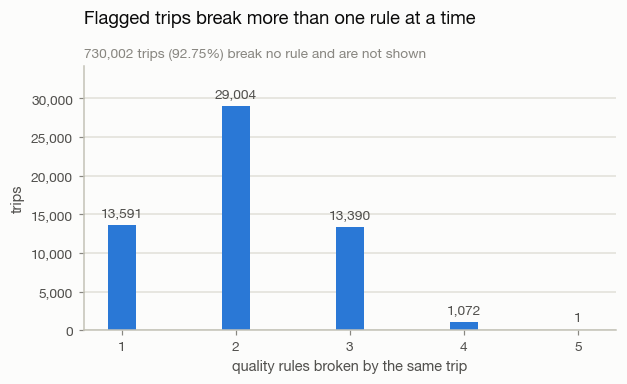

In [3]:
flags = analytics.read("""
    SELECT suspect_flags AS flags_per_trip, COUNT(*) AS trips
    FROM Taxi.TripQuality
    WHERE suspect_flags > 0
    GROUP BY suspect_flags
    ORDER BY suspect_flags
""")

fig, ax = plt.subplots(figsize=(5.8, 3.6))
width = plotstyle.bar_thickness(ax, len(flags), px=24, category_axis="x")
bars = ax.bar(flags.flags_per_trip, flags.trips, width=width,
              color=plotstyle.SERIES)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9,
             color=plotstyle.INK_2)

clean = total_trips - suspect_trips
ax.set_title("Flagged trips break more than one rule at a time")
plotstyle.subtitle(ax, f"{clean:,} trips ({clean / total_trips * 100:.2f}%) "
                       "break no rule and are not shown")
ax.set_xlabel("quality rules broken by the same trip")
ax.set_ylabel("trips")
ax.set_xticks(flags.flags_per_trip)
ax.set_ylim(0, flags.trips.max() * 1.18)
ax.grid(axis="x", visible=False)
plotstyle.thousands(ax)
plt.tight_layout()
plt.show()

Only 13,591 of the 57,058 flagged trips break exactly one rule. **Three quarters
break two or more**, which is the useful finding: bad records cluster instead of
spreading evenly, so a small number of upstream causes explains most of them —
a fare opened and closed on the spot produces zero distance, sub-minute
duration, and a charge without movement all at once.

## Part 2 — Enrichment: where are the trips?

`pu_location_id = 74` is not an answer to "where are the busiest pickups".
`Taxi.TripEnriched` joins `Taxi.Zone` to both ends of every trip and adds the
calendar parts of the pickup timestamp, so the questions below are plain
`GROUP BY`s that IRIS can answer without sending a single trip row to Python.

It also carries `is_suspect`, computed from the *same* thirteen predicates that
define `Taxi.SuspectTrip` — imported in Python, not retyped. That is what turns
the quality workflow from a report into a gate: `WHERE is_suspect = 0` is how a
fare average stops being dragged around by a 278,990-mile trip.

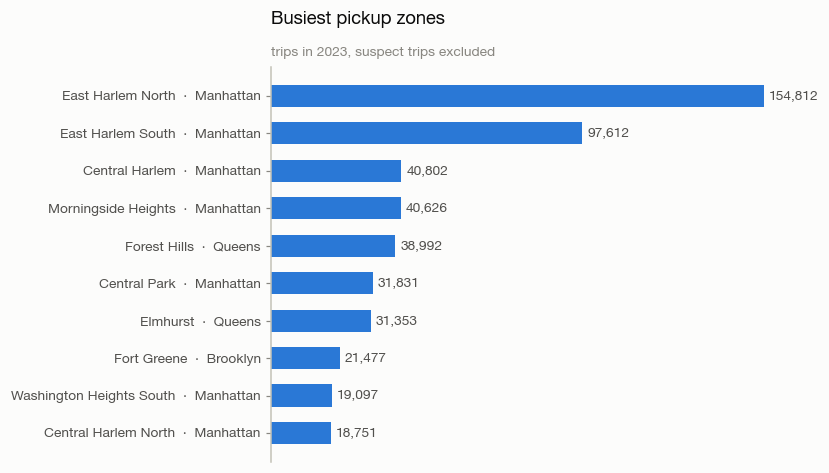

,zone,borough,trips,avg_fare,avg_tip,avg_miles,avg_minutes
0,East Harlem North,Manhattan,154812,14.59,2.47,2.33,12.9
1,East Harlem South,Manhattan,97612,14.82,2.33,2.41,13.0
2,Central Harlem,Manhattan,40802,14.64,1.77,2.40,12.8
3,Morningside Heights,Manhattan,40626,16.20,2.76,2.71,14.0
4,Forest Hills,Queens,38992,16.68,1.76,2.79,14.2
5,Central Park,Manhattan,31831,15.46,2.87,2.42,14.0
6,Elmhurst,Queens,31353,17.97,1.73,3.10,15.9
7,Fort Greene,Brooklyn,21477,17.40,2.63,2.60,16.9
8,Washington Heights South,Manhattan,19097,25.15,3.61,5.23,18.9
9,Central Harlem North,Manhattan,18751,15.77,1.38,2.74,13.6


In [4]:
zones_top = analytics.busiest_zones("pickup", top=10)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
y = range(len(zones_top))
ax.barh(y, zones_top.trips, color=plotstyle.SERIES,
        height=plotstyle.bar_thickness(ax, len(zones_top)))
ax.set_yticks(list(y))
ax.set_yticklabels([f"{z}  ·  {b}" for z, b in
                    zip(zones_top.zone, zones_top.borough)])
ax.invert_yaxis()
plotstyle.label_bar_ends(ax, zones_top.trips.tolist())
plotstyle.strip_x_axis(ax)   # the labels are the value axis

ax.set_title("Busiest pickup zones")
plotstyle.subtitle(ax, "trips in 2023, suspect trips excluded")
plt.tight_layout()
plt.show()

zones_top

East Harlem alone accounts for **252,424 pickups — a third of the clean year**,
and the top ten are almost entirely northern Manhattan plus Queens. That is not
a data artefact, it is regulation showing up in data: green taxis may not accept
street hails in the Manhattan core below 96th Street, so the fleet works exactly
the areas yellow cabs under-serve.

The drop-off ranking (`analytics.busiest_zones("dropoff")`) is a different
question with a different answer — LaGuardia Airport appears there and nowhere in
the pickup list, at a $25.60 average fare against the $14–18 typical elsewhere.

## Part 3 — Activity through the day and the year

Both cuts come from `DATEPART` columns in the view, so IRIS returns 24 rows and
12 rows respectively. Doing the same in pandas means shipping 787,060 timestamps
across the wire to compute 24 numbers.

Trips and average fare are plotted as **two panels rather than two y-axes**:
putting a 4,000–57,000 count and a $16–24 fare on one pair of axes invents a
relationship the data does not contain.

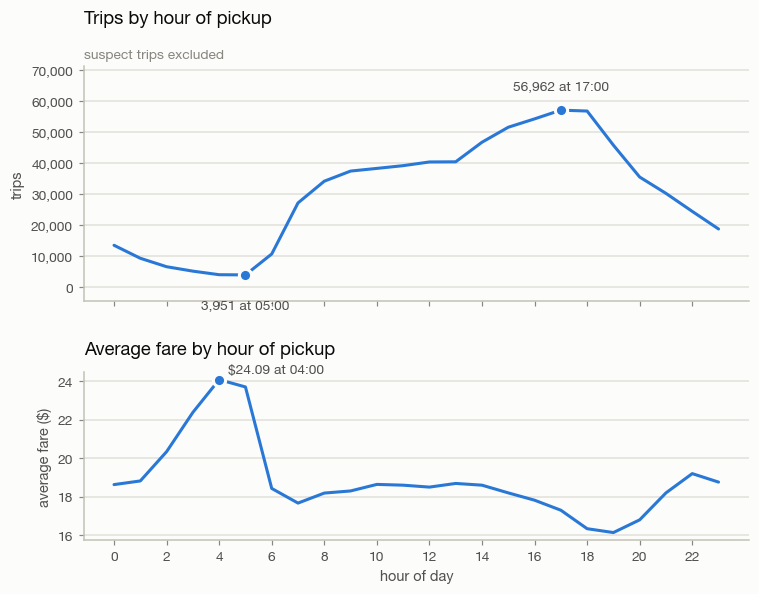

In [5]:
hourly = analytics.hourly_activity()

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7.8, 5.6), sharex=True,
    gridspec_kw={"height_ratios": [1.4, 1], "hspace": 0.35})

ax_top.plot(hourly.hour_of_day, hourly.trips, color=plotstyle.SERIES)
peak = hourly.loc[hourly.trips.idxmax()]
trough = hourly.loc[hourly.trips.idxmin()]
# The trough label goes *below* its point: the space above it is where the
# morning ramp climbs through, and a label there sits on the line.
for point, offset, va in ((peak, (0, 12), "bottom"), (trough, (0, -16), "top")):
    ax_top.plot(point.hour_of_day, point.trips, "o",
                color=plotstyle.SERIES, markeredgecolor=plotstyle.SURFACE,
                markeredgewidth=2)
    ax_top.annotate(f"{int(point.trips):,} at {int(point.hour_of_day):02d}:00",
                    xy=(point.hour_of_day, point.trips), textcoords="offset points",
                    xytext=offset, ha="center", va=va, fontsize=9,
                    color=plotstyle.INK_2)
ax_top.set_title("Trips by hour of pickup")
plotstyle.subtitle(ax_top, "suspect trips excluded")
ax_top.set_ylabel("trips")
ax_top.set_ylim(-hourly.trips.max() * 0.08, hourly.trips.max() * 1.25)
ax_top.grid(axis="x", visible=False)
plotstyle.thousands(ax_top)

ax_bot.plot(hourly.hour_of_day, hourly.avg_fare, color=plotstyle.SERIES)
night = hourly.loc[hourly.avg_fare.idxmax()]
ax_bot.plot(night.hour_of_day, night.avg_fare, "o", color=plotstyle.SERIES,
            markeredgecolor=plotstyle.SURFACE, markeredgewidth=2)
ax_bot.annotate(f"${night.avg_fare:.2f} at {int(night.hour_of_day):02d}:00",
                xy=(night.hour_of_day, night.avg_fare),
                textcoords="offset points", xytext=(6, 4), ha="left",
                fontsize=9, color=plotstyle.INK_2)
ax_bot.set_title("Average fare by hour of pickup")
ax_bot.set_ylabel("average fare ($)")
ax_bot.set_xlabel("hour of day")
ax_bot.set_xticks(range(0, 24, 2))
ax_bot.grid(axis="x", visible=False)

plt.show()

Volume peaks at **17:00 (56,962 trips)** and bottoms out at **05:00 (3,951)** — a
14× swing. Average fare moves the opposite way: the quietest hours are the most
expensive ones (**$24.09 at 04:00** against $16.35 at 18:00), because the few
trips being taken then are long ones. Two measures, opposite shapes, and a
dual-axis chart would have implied they were the same story.

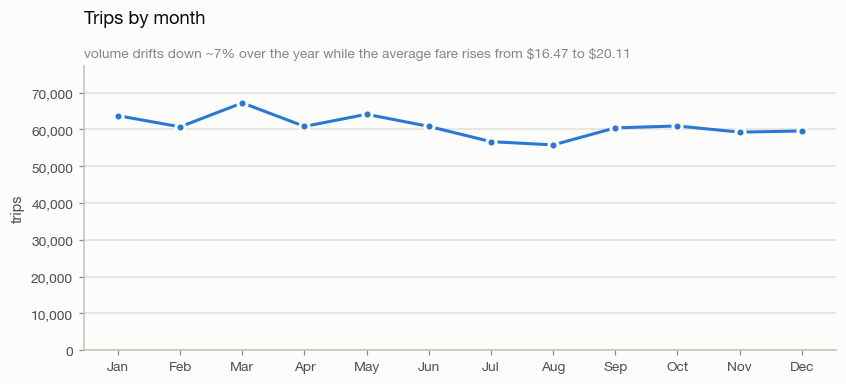

,month_no,month_name,trips,avg_fare,revenue
0,1,January,63724,16.47,1388599
1,2,February,60696,16.52,1329872
2,3,March,67201,16.88,1500119
3,4,April,60809,17.44,1399378
4,5,May,64111,17.92,1519928
5,6,June,60818,18.50,1477228
6,7,July,56673,18.55,1374167
7,8,August,55787,18.99,1389736
8,9,September,60419,20.11,1583862
9,10,October,60930,18.80,1499975


In [6]:
monthly = analytics.monthly_activity()

fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.plot(monthly.month_no, monthly.trips, color=plotstyle.SERIES)
ax.plot(monthly.month_no, monthly.trips, "o", color=plotstyle.SERIES,
        markeredgecolor=plotstyle.SURFACE, markeredgewidth=2, markersize=6)
ax.set_title("Trips by month")
# Dollar signs escaped: a pair of bare $ makes matplotlib render the span as
# italic mathtext and eat both symbols.
plotstyle.subtitle(
    ax, "volume drifts down ~7% over the year while the average fare rises "
        rf"from \${monthly.avg_fare.iloc[0]:.2f} to \${monthly.avg_fare.max():.2f}")
ax.set_ylabel("trips")
plotstyle.thousands(ax)
ax.set_xticks(monthly.month_no)
ax.set_xticklabels([n[:3] for n in monthly.month_name])
ax.set_ylim(0, monthly.trips.max() * 1.15)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

monthly

## Part 4 — What a trip costs, compared across boroughs

Two things worth stating about how these numbers are computed, because both are
easy to get wrong and neither error announces itself:

* **Fare per mile is `SUM(fare) / SUM(miles)`, not `AVG(fare / miles)`.** The
  per-row ratio is dominated by short trips, where the flag drop makes every mile
  look expensive; the ratio of sums is the fare per mile actually paid.
* **Tip figures use card payments only.** Of 228,487 clean cash trips, exactly
  **2** carry a non-zero tip, against 406,093 of 446,136 card trips. Cash tips
  simply are not recorded, so averaging tips over all payment types measures the
  card share, not generosity — and understates the real tip rate by about a third.

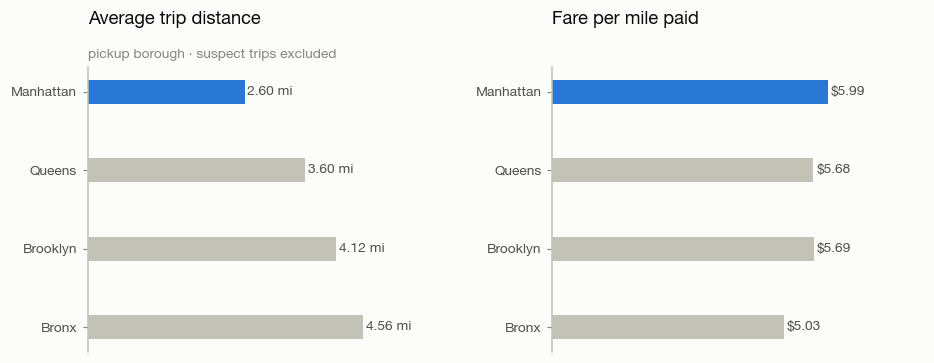

,borough,trips,avg_miles,avg_minutes,avg_fare,fare_per_mile,revenue
0,Manhattan,430018,2.60,13.5,15.59,5.99,9270293
1,Queens,189577,3.60,16.9,20.43,5.68,4818311
2,Brooklyn,98104,4.12,20.7,23.44,5.69,2881670
3,Bronx,11643,4.56,19.8,22.92,5.03,312811
4,N/A,367,13.26,39.1,63.12,4.76,25693
5,Unknown,213,3.08,14.7,18.57,6.03,4761
6,Staten Island,65,6.30,19.5,26.93,4.28,2184
7,EWR,15,11.91,28.1,100.46,8.43,1848


In [7]:
boroughs = analytics.borough_economics()
main = boroughs[boroughs.borough.isin(
    ["Manhattan", "Queens", "Brooklyn", "Bronx"])].reset_index(drop=True)

# Staten Island (65 trips), EWR (15), and the lookup's own 'Unknown'/'N/A'
# entries (580 together) are left out of the chart on purpose — at those counts
# a bar is noise presented as a finding. They stay in the table below.
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
for ax, column, title, fmt in (
        (axes[0], "avg_miles", "Average trip distance", "{:,.2f} mi"),
        (axes[1], "fare_per_mile", "Fare per mile paid", "${:,.2f}")):
    # Emphasis, not eight hues: Manhattan is the point of both panels, the rest
    # are context.
    colors = [plotstyle.SERIES if b == "Manhattan" else plotstyle.DEEMPH
              for b in main.borough]
    y = range(len(main))
    ax.barh(y, main[column], color=colors,
            height=plotstyle.bar_thickness(ax, len(main)))
    ax.set_yticks(list(y))
    ax.set_yticklabels(main.borough)
    ax.invert_yaxis()
    plotstyle.label_bar_ends(ax, main[column].tolist(), fmt=fmt)
    plotstyle.strip_x_axis(ax)
    # pad=28 on both panels even though only the left one carries a subtitle:
    # subtitle() raises the left title, and without the matching pad the two
    # panel titles sit at different heights and read as a misalignment.
    ax.set_title(title, pad=28)
    ax.set_xlim(0, main[column].max() * 1.35)

plotstyle.subtitle(axes[0], "pickup borough · suspect trips excluded")
plt.tight_layout()
plt.show()

boroughs

Manhattan runs **the shortest trips (2.60 miles) at the highest price per mile
($5.99)**, and the Bronx the opposite (4.56 miles at $5.03) — the same cause
seen twice, since a flat flag drop spread over fewer miles makes each mile dearer.

The right-hand panel is also a small lesson in reading charts honestly. Its bars
look nearly equal because they nearly are: 19% separates the extremes, against
75% on the distance panel. Both axes start at zero, so the eye gets the true
proportion and the labels carry the precision — a truncated axis would have
turned a modest spread into a dramatic-looking one.

`analytics.tipping_by_zone()` adds the tipping angle, with a 1,000-trip floor so
the ranking is not a list of zones with a freak average: card tips run
**20–24% of fare** in the top zones, led by Upper East Side North (23.8%) and
Central Park (23.0%).

## Part 5 — Where the trips actually go

The unfiltered origin→destination ranking is dominated by short hops inside East
Harlem, which is true and not very informative. Restricting to trips that cross a
borough line shows the corridors that connect the city — and the airports
immediately dominate.

In [8]:
analytics.od_pairs(top=10, cross_borough_only=True)

,origin,origin_borough,destination,dest_borough,trips,avg_fare,avg_miles,avg_minutes
0,East Harlem North,Manhattan,LaGuardia Airport,Queens,2798,28.75,6.70,16.3
1,East Harlem North,Manhattan,Mott Haven/Port Morris,Bronx,1148,12.42,1.71,11.2
2,East Harlem South,Manhattan,LaGuardia Airport,Queens,826,34.23,7.98,22.5
3,Central Harlem,Manhattan,LaGuardia Airport,Queens,589,31.89,7.49,21.7
4,East Harlem North,Manhattan,East Concourse/Concourse Village,Bronx,534,16.48,2.56,15.5
5,Jamaica,Queens,Outside of NYC,N/A,517,63.71,13.65,33.1
6,East Harlem North,Manhattan,JFK Airport,Queens,516,69.06,17.06,43.2
7,East Harlem South,Manhattan,Mott Haven/Port Morris,Bronx,512,16.95,2.78,15.7
8,Morningside Heights,Manhattan,LaGuardia Airport,Queens,505,37.88,8.36,29.0
9,Downtown Brooklyn/MetroTech,Brooklyn,LaGuardia Airport,Queens,500,45.59,10.54,24.1


LaGuardia is the single strongest cross-borough destination (2,798 trips from
East Harlem North alone, at $28.75 average). JFK runs $69–71 and 43–58 minutes.
The one row that is *not* an airport is `Jamaica → Outside of NYC`, 517 trips at
$63.71 — the lookup's own catch-all zone, which is the honest way for a location
table to say "the trip left the city".

## Part 6 — The stretch goal: push the work down, or pull the data up?

The brief asks three questions that are answerable rather than debatable: how
much data has to move between IRIS and Python, which approach is easier to
develop and maintain, and which one you would want if the data set grew. So this
part measures them, with **six different routes to the same seven answers**:

| Arm | What it does |
|---|---|
| push-down, IRIS view | `GROUP BY` inside IRIS over `Taxi.TripEnriched` |
| push-down, materialised (row) | the same SQL over a stored copy, `Taxi.TripFlat` |
| push-down, materialised (columnar) | the same SQL over a column-stored copy |
| pull-up | IRIS as a dumb store: `SELECT` all 787,060 rows, aggregate in pandas |
| no IRIS, cold | no database at all — re-parse the 105 MB CSV every session |
| no IRIS, cached | no database, but parse once and reuse a pickled frame |

The last two are `src/pure_python.py`, which imports nothing from IRIS and
re-derives all 16 quality rules, the enrichment and all seven workflows in pandas.
It exists so this comparison has a real opponent instead of a strawman: **every
arm below is checked to produce the same numbers**, and that check is what makes
the timings mean anything.

Three decisions keep the measurement honest rather than flattering:

* **Each arm runs in its own subprocess.** Peak memory (`ru_maxrss`) is a
  high-water mark, so six arms in one process would all report the peak of the
  greediest one.
* **Both sides get to prepare once.** The first version of this comparison put an
  IRIS *view* — 16 `CASE` expressions and two joins, re-evaluated on every read —
  against a pandas frame that had already been built, and pandas duly won.
  `src/build_flat.py` exists because of that result. Preparation cost is not
  hidden; it is its own table.
* **Cold and warm are separate columns.** First execution pays for statement
  preparation on one side and for import warm-up on the other. Quoting either
  number alone picks the winner in advance.

In [9]:
import compare_approaches

# Runs all six arms, one subprocess each (~40 s), and returns the same frames
# `python src/compare_approaches.py` prints — so this table cannot drift from
# the script's. rebuild=False reuses the materialised copies if they exist.
frames = compare_approaches.run_all(rebuild=False)
frames["timings"]

Preparing both sides (materialised IRIS copies, pandas cache) …
Running each arm in its own process, for honest peak memory:
  pushdown …


  pushdown_flat …


  pushdown_col …


  pullup …


  csv_cold …


  csv_cached …


,approach,setup (s),1 question cold (s),1 question warm (s),7 questions (s),rows into Python,MB off disk,peak RAM (MB)
0,"push-down, IRIS view",0.02,0.765,0.749,6.19,96,0.0,65.2
1,"push-down, materialised (row)",0.02,0.595,0.574,2.10,96,0.0,65.4
2,"push-down, materialised (columnar)",0.02,0.270,0.250,1.38,96,0.0,65.4
3,"pull-up, all rows -> pandas",4.58,0.089,0.080,0.55,787325,0.0,2569.6
4,"no IRIS, cold (re-parse CSV)",2.49,0.085,0.085,0.57,787060,105.1,1490.9
5,"no IRIS, cached (pickled frame)",0.11,0.104,0.084,0.57,787060,174.8,896.3


**pandas wins the seconds column, and that is the honest headline.** At this size
the whole year fits in memory, so once the frame is built, a `groupby` over 787k
rows in C beats a round trip to a database — 0.55 s for all seven questions
against 1.56 s for the fastest IRIS arm. Reporting the reverse would need either a
bigger file or a quieter method.

What the same table shows is *what that speed costs*, and it is the answer to the
brief's first question:

* **Data moved: 96 rows against 787,060.** The push-down arms move the answer;
  the pull-up arm moves the raw material and computes the answer on this side of
  the wire. That is a factor of ~8,200 in rows crossing a socket, and 20 columns
  per row rebuilt as Python objects.
* **Peak memory: 65 MB against 900–2,570 MB.** The IRIS arms hold seven small
  result frames; the pandas arms hold the year. The pull-up arm is the worst of
  all (2.6 GB) because it pays for the fetched tuples *and* the frame built from
  them.
* **Storage layout is a real lever, inside the database.** The same seven
  statements run 4× faster over the columnar copy than over the view (1.56 s vs
  6.18 s), with a one-line DDL change (`WITH STORAGETYPE = COLUMNAR`) and no
  change to any query. Confirmed rather than assumed — `build_flat.storage_type()`
  reads it back from `%Dictionary.CompiledParameter`.

In [10]:
# The whole comparison rests on this: same answers, or nothing below means
# anything. Every arm is checked against push-down over the view.
frames["agreement"]

,arm,same keys,largest numeric gap,verdict
0,"push-down, materialised (row)",True,0.0,identical
1,"push-down, materialised (columnar)",True,0.0,identical
2,"pull-up, all rows -> pandas",True,0.0,identical
3,"no IRIS, cold (re-parse CSV)",True,0.0,identical
4,"no IRIS, cached (pickled frame)",True,0.0,identical


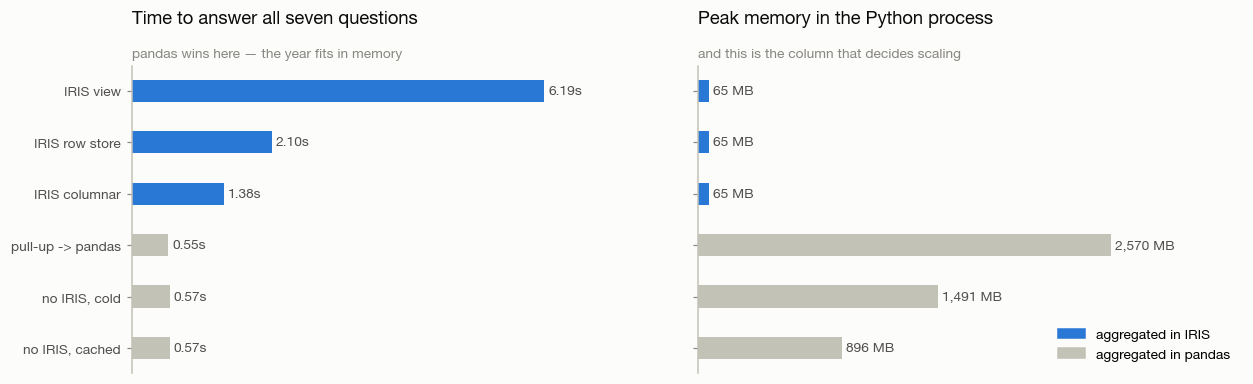

In [11]:
from matplotlib.patches import Patch

chart = frames["timings"].copy()
chart["short"] = ["IRIS view", "IRIS row store", "IRIS columnar",
                  "pull-up -> pandas", "no IRIS, cold", "no IRIS, cached"]
# Colour follows *where the aggregation happens*, not rank, and it stays put
# across both panels — that is what makes the trade-off legible: the same blue
# loses the left panel and wins the right one.
in_iris = [True, True, True, False, False, False]
chart = chart.iloc[::-1].reset_index(drop=True)   # barh draws bottom-up
colors = [plotstyle.SERIES if flag else plotstyle.DEEMPH
          for flag in in_iris[::-1]]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
panels = (("7 questions (s)", "Time to answer all seven questions", "{:,.2f}s",
           "pandas wins here — the year fits in memory"),
          ("peak RAM (MB)", "Peak memory in the Python process", "{:,.0f} MB",
           "and this is the column that decides scaling"))
for ax, (column, title, fmt, note) in zip(axes, panels):
    ax.barh(chart.short, chart[column],
            height=plotstyle.bar_thickness(ax, len(chart)), color=colors)
    ax.set_title(title)
    ax.set_xlim(0, chart[column].max() * 1.32)
    plotstyle.label_bar_ends(ax, chart[column].tolist(), fmt=fmt)
    plotstyle.strip_x_axis(ax)
    plotstyle.subtitle(ax, note)

axes[1].legend(handles=[Patch(color=plotstyle.SERIES, label="aggregated in IRIS"),
                        Patch(color=plotstyle.DEEMPH, label="aggregated in pandas")],
               loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Preparation is what each side pays once, and only what this run actually built
# is timed — reporting a cache *load* as a build cost would be exactly the kind
# of quiet lie this part is trying to avoid.
prep = frames["preparation"]
prep if len(prep) else (
    "Nothing was rebuilt in this run: the materialised copies and the pandas "
    "cache already existed. `python src/compare_approaches.py` tears them down "
    "and times the rebuild — Taxi.TripFlat ~9s, the columnar copy ~11s, the "
    "pandas pickle cache ~2.7s. Loading the CSV into Taxi.Trip in the first "
    "place is a further one-time cost, measured by src/load_trips.py.")

'Nothing was rebuilt in this run: the materialised copies and the pandas cache already existed. `python src/compare_approaches.py` tears them down and times the rebuild — Taxi.TripFlat ~9s, the columnar copy ~11s, the pandas pickle cache ~2.7s. Loading the CSV into Taxi.Trip in the first place is a further one-time cost, measured by src/load_trips.py.'

In [13]:
frames["code"].groupby("route")["code lines"].sum()

route
IRIS route               707
IRIS route (optional)     73
pandas route             367
Name: code lines, dtype: int64

That last number is the answer to the brief's second question, and it needs
reading carefully rather than as a scoreboard. **707 lines for the IRIS route
against 367 for pandas** — the no-database route is genuinely *less* code, because
the IRIS route includes its schema, its validator and its loaders, code that runs
once but still has to be maintained.

The difference is not volume, it is *duplication*. Those 367 lines re-derive, in
Python, definitions that already exist in SQL: the 16 quality rules, the parsing
of `MM/DD/YYYY hh:mm:ss AM/PM`, the borough join, the day-of-week convention. Two
copies of a rule are two things that can disagree — and while writing this
comparison, they did. Both bugs were found by the agreement check and by nothing
else:

* **The borough literally named `N/A`.** LocationID 265's borough is the string
  `'N/A'`, which is in pandas' default missing-value list, so 367 trips silently
  lost their borough. A `VARCHAR` column has no opinion about which strings mean
  absent; `read_csv` has a list of nineteen, and it is on by default.
* **A cache with no invalidation.** After fixing the first bug the cached arm
  *still* disagreed — it was serving answers computed under the old rule. A view
  cannot go stale, because it holds no answers. Fixing this needed a fingerprint
  (file size, mtime, column list, a hash of the rule bytecode) which is 15 lines
  of the kind of code databases exist so you don't write.

A third one landed on the IRIS side, so this is not a one-sided lesson:
`%EXACT()` in a view **does not survive materialisation**. Copying the view into a
new table gives its `VARCHAR` columns the default `SQLUPPER` collation back, so
`GROUP BY pu_borough` over the copy returns `MANHATTAN`. Nothing errors, no number
changes, every chart label just starts shouting — and the columnar copy did not
have the problem, so testing one layout would have missed it. `build_flat.py`
generates its DDL with explicit `COLLATE EXACT` for that reason.

**Which one would I want if the data grew?** IRIS, and the evidence is the memory
column, not the seconds column. The pandas route's cost is proportional to the
data: 787k rows already peak at 0.9–2.6 GB, so ten times the data is 9–26 GB and
the arm stops working on this laptop — while the IRIS answer stays 96 rows and 65
MB no matter how large the table gets, and the storage layout is a lever you can
still pull. The break-even point is memory, not speed, and it is much closer than
the seconds column suggests.

## What is not in here yet

Named because a prototype that hides its edges is not a useful prototype:

* **Embedded Python** — the aggregation running *inside* the database process as a
  class method, with no wire at all. It is the one arm of the stretch goal not
  measured here, and the one most likely to change the seconds column, since it
  removes both the socket and the object conversion.
* **Server-side `LOAD DATA` vs client-side `executemany`** for the load itself.
  This project loads via `executemany`; IRIS's own bulk loader would be the
  faster route and the comparison is not made.
* **A bigger file.** Every conclusion above is drawn at 787k rows / 105 MB, where
  the whole data set fits in RAM. The interesting measurement is the one that
  crosses that line, and this laptop cannot make it.
* **`Taxi.TripQuality` is still a view for the notebook's own charts.** Its 16
  `CASE` expressions are recomputed on every read; Part 6 shows what materialising
  them buys (4×), but the charts above deliberately read the view, because the
  view is the definition.
* **The three `component_sum_mismatch` signatures deserve a second look with the
  TLC data dictionary** in hand. The pattern is unambiguous; the explanation for
  *why* the feed writes `mta_tax = 1.50` is still a hypothesis.